# freeCAM PI-atm

This notebook follows the same object-oriented UI as FreeCESM. Machine paths, run-directory preparation, PBS submission, `mpiexec`, and the persistent socket are implementation details hidden by `freecam.Driver`.

In [1]:
%load_ext autoreload
%autoreload 2

import freecam as fc
import numpy as np

## 1. Create one model

Constructing the driver is cheap and does not submit a job. A `CaseConfig` can declare a custom atmosphere workflow before MPI starts. Its factory receives the complete validated default order, so it only needs to describe the changes. Here the same Python physics class is inserted twice; freeCAM creates two independent runtime process instances.

In [2]:
class VolcanicAerosol(fc.Physics):
    name = 'volcanic_aerosol'
    writes = ('phys_state.t',)

    def run(self, state, context):
        state.T += 1.0e-4


def volcanic_workflow(default):
    workflow = default.copy()
    workflow.insert_after('dadadj', VolcanicAerosol())
    workflow.insert_before('radiation_tend', VolcanicAerosol())
    return workflow


volcanic_case = fc.CaseConfig(
    name='PI-atm-volcanic',
    description='PI-atm with two Python aerosol tendencies',
    forcing='1850 prescribed SST and sea ice plus volcanic aerosol',
    make_atm=lambda: fc.FreeCAM(workflow=volcanic_workflow),
)

fc.CASES.register(volcanic_case, replace=True)
driver = fc.Driver(
    case='PI-atm-volcanic',
    nsteps=2,
    history_every=1,
    restart_every='end',
    # This experiment intentionally changes CAM output, so replay only x2a inputs.
    verify_boundary_exports=False,
)
display(driver.preview().describe())  # does not submit PBS or start MPI
print(driver.case)
print('50-step validation:', driver.validation.get('bfb', 'see validation record'))

({'index': 0,
  'name': 'boundary_import',
  'operation': 'boundary_import',
  'kind': 'boundary',
  'implementation': 'fortran-numerical-kernel'},
 {'index': 1,
  'name': 'prepare',
  'operation': 'prepare',
  'kind': 'kernel',
  'implementation': 'fortran-numerical-kernel'},
 {'index': 2,
  'name': 'surface_fluxes_and_emissions',
  'operation': 'chem_emissions',
  'kind': 'scheme',
  'implementation': 'fortran-numerical-kernel'},
 {'index': 3,
  'name': 'tracer_tendencies_leaf',
  'operation': 'leaf_tracers_timestep_tend',
  'kind': 'scheme',
  'implementation': 'fortran-numerical-kernel'},
 {'index': 4,
  'name': 'age_of_air_tendencies_leaf',
  'operation': 'leaf_aoa_tracers_timestep_tend',
  'kind': 'scheme',
  'implementation': 'fortran-numerical-kernel'},
 {'index': 5,
  'name': 'chemistry_tendencies_leaf',
  'operation': 'leaf_chem_timestep_tend',
  'kind': 'scheme',
  'implementation': 'fortran-numerical-kernel'},
 {'index': 6,
  'name': 'vertical_diffusion',
  'operation': 've

PI-atm-volcanic: PI-atm with two Python aerosol tendencies [1850 prescribed SST and sea ice plus volcanic aerosol]
50-step validation: True


PI-CAM Notebook worker submitted as 7102059.desched1; waiting for 512 ranks ...
rank=0   step=0   date=10101   T_mean=245.12 K   u_mean=3.69 m/s   v_mean=-0.60 m/s   q_mean=2.872 g/kg
global mean T: 242.86870659185382
top-level mean T: 236.23542066773427
persistent job: managed by Driver
run directory: /glade/derecho/scratch/ruitong/freeCAM/PI-cam/notebook-20260812-123559-c3a76eff/run


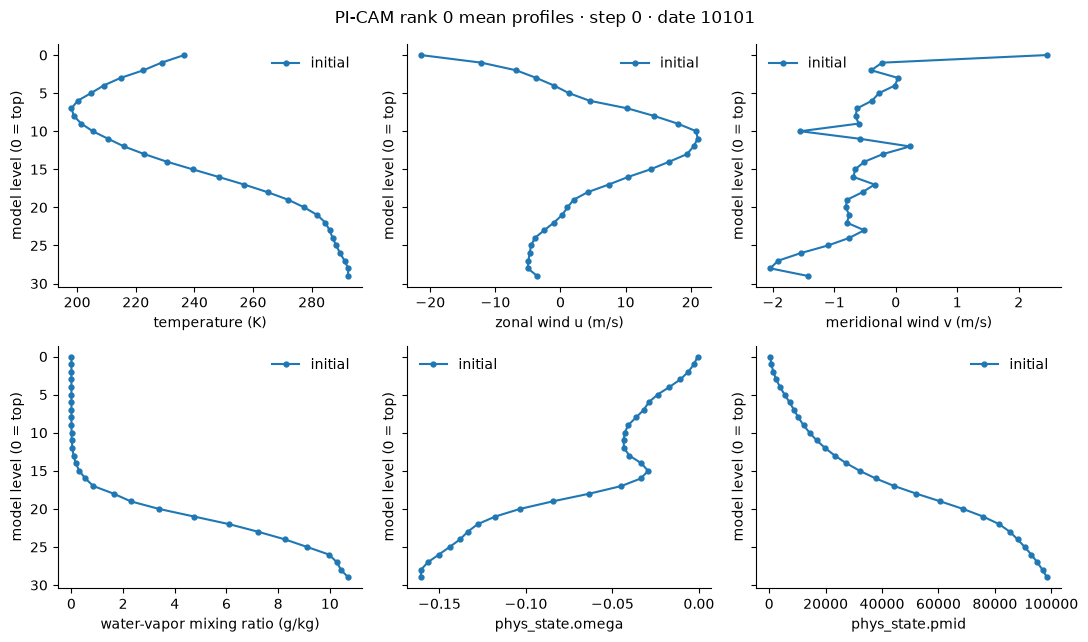

In [3]:
plot_variables = (
    'T', 'u', 'v', 'q',
    'phys_state.omega', 'phys_state.pmid',
)
fig, axes = driver.cam.state.plot(
    rank=0, variables=plot_variables, figsize=(11, 6.5), label='initial'
)
print(driver.cam.state.summary(rank=0))
print('global mean T:', driver.cam.state.T.mean())
print('top-level mean T:', driver.cam.state.T[:, 0, :].mean())
print('persistent job:', driver.cam.status.get('job_id', 'managed by Driver'))
print('run directory:', driver.run_dir)

## 2. Inspect and run the Python-owned workflow

The workflow is the complete per-step running order, written as one explicit Python list just like FreeCESM. Assigning the list installs that exact order atomically on every MPI rank. The default is already expanded to validated leaf processes: Python owns every ordering and alarm decision, while each row states whether its primitive is Python, a Fortran numerical kernel, or a low-level state/PIO/clock service. Internal CAM phase names are not part of this user interface; edit the order below and assign the new list.

In [4]:
# Resolve the live process handles once, then define the complete order directly.
process = {item.operation: item for item in driver.cam.workflow}
configured = {item.name: item for item in driver.cam.configured_processes}

pi_cam_workflow = [
    process['boundary_import'],
    process['prepare'],
    process['chem_emissions'],
    process['leaf_tracers_timestep_tend'],
    process['leaf_aoa_tracers_timestep_tend'],
    process['leaf_chem_timestep_tend'],
    process['vertical_diffusion_tend'],
    process['rayleigh_friction_tend'],
    process['leaf_aero_model_drydep'],
    process['leaf_carma_timestep_tend'],
    process['charge_fix'],
    process['gw_tend'],
    process['qbo_relax'],
    process['iondrag_calc'],
    process['physics_dme_adjust'],
    process['leaf_carma_accumulate_stats'],
    process['leaf_pbuf_deallocate'],
    process['leaf_pbuf_update_tim_idx'],
    process['leaf_diag_deallocate'],
    process['stepon_run2'],
    process['stepon_run3'],
    process['wshist'],
    process['restart'],
    process['leaf_cam_run4_wrapup'],
    process['leaf_cam_run4_step_cost'],
    process['leaf_cam_run4_flush'],
    process['advance_timestep'],
    process['stepon_run1'],
    process['prepare_cam_run1'],
    process['bc_init'],
    process['check_energy_fix'],
    process['dadadj'],
    configured['volcanic_aerosol_1'],
    process['convect_deep_tend'],
    process['convect_shallow_tend'],
    process['sslt_rebin_adv'],
    process['macro_microphysics'],
    process['leaf_modal_aero_prepare'],
    process['leaf_aero_model_wetdep'],
    process['leaf_carma_wetdep_tend'],
    process['leaf_convect_deep_tend_2'],
    process['leaf_diag_phys_writeout'],
    process['leaf_cloud_diagnostics_calc'],
    configured['volcanic_aerosol_2'],
    process['radiation_tend'],
    process['leaf_tropopause_output'],
    process['leaf_cam_export'],
    process['leaf_diag_export'],
    process['boundary_export'],
]

driver.cam.workflow = pi_cam_workflow
driver.cam.workflow

#,process,operation,kind,control,implementation
0,boundary_import,boundary_import,boundary,python,fortran-numerical-kernel
1,prepare,prepare,kernel,python,fortran-numerical-kernel
2,surface_fluxes_and_emissions,chem_emissions,scheme,python,fortran-numerical-kernel
3,tracers_and_chemistry,tracers_chemistry,scheme,python,fortran-numerical-kernel
4,tracer_tendencies_leaf,leaf_tracers_timestep_tend,scheme,python,fortran-numerical-kernel
5,age_of_air_tendencies_leaf,leaf_aoa_tracers_timestep_tend,scheme,python,fortran-numerical-kernel
6,chemistry_tendencies_leaf,leaf_chem_timestep_tend,scheme,python,fortran-numerical-kernel
7,vertical_diffusion,vertical_diffusion_tend,scheme,python,fortran-numerical-kernel
8,rayleigh_friction,rayleigh_friction_tend,scheme,python,fortran-numerical-kernel
9,aerosol_dry_deposition,aero_model_drydep,scheme,python,fortran-numerical-kernel


In [5]:
trace = driver.run(verbose=False)
print(f'executed {len(trace)} actions across {driver.nsteps} complete steps')
print('first process:', trace[0]['name'])
print('last process: ', trace[-1]['name'])

for axis, variable in zip(axes.flat, plot_variables):
    driver.cam.state.plot_profile(
        variable, rank=0, ax=axis, color='tab:orange', label='after 2 steps'
    )
print(driver.cam.state.summary(rank=0))

executed 98 actions across 2 complete steps
first process: boundary_import
last process:  boundary_export
rank=0   step=2   date=10101   T_mean=245.28 K   u_mean=3.55 m/s   v_mean=-1.07 m/s   q_mean=2.876 g/kg


## 3. Add a variable and a Python physics process

Use an ordinary NumPy array for small rank-independent state: freeCAM copies the same shape and values into every rank's StatePool. Use `fc.Variable(dims=...)` when a field follows CAM's distributed grid and therefore has a rank-local shape. NumPy expressions are sent as compact trees and evaluated against local arrays on every rank. A `Physics` object can then be appended or inserted directly into the live workflow.

In [6]:
NLEV = driver.cam.state.T.metadata['shape'][1]
driver.cam.state.rh = np.zeros(NLEV)  # same 1-D profile on every rank

driver.cam.state.experiment_tracer = fc.Variable(
    dims=('pcols', 'pver', 'chunks'),
    units='kg kg-1',
    initial=0.0,
    aliases=('tracer',),
    standard_name='experiment_tracer',
)

class NotebookTracer(fc.Physics):
    name = 'notebook_tracer_source'
    after = 'dadadj'
    writes = ('tracer',)

    def run(self, state, context):
        state.tracer += 1.0e-6 * context.timestep_seconds

tracer_process = driver.cam.workflow.append(NotebookTracer())
tracer_process.move(after='dadadj')
driver.cam.state.T[:, 0, :] += 0.0  # collective no-op slice edit
driver.cam.state.rh = np.clip(driver.cam.state.rh + 0.05, 0.0, 1.0)
driver.cam.state.experiment_tracer = np.sin(driver.cam.state.experiment_tracer)
print('StatePool fields:', len(driver.cam.state))
print('global mean RH diagnostic:', driver.cam.state.rh.mean())
driver.cam.workflow

StatePool fields: 153
global mean RH diagnostic: 0.05000000000000002


#,process,operation,kind,control,implementation
0,boundary_import,boundary_import,boundary,python,fortran-numerical-kernel
1,prepare,prepare,kernel,python,fortran-numerical-kernel
2,surface_fluxes_and_emissions,chem_emissions,scheme,python,fortran-numerical-kernel
3,tracers_and_chemistry,tracers_chemistry,scheme,python,fortran-numerical-kernel
4,tracer_tendencies_leaf,leaf_tracers_timestep_tend,scheme,python,fortran-numerical-kernel
5,age_of_air_tendencies_leaf,leaf_aoa_tracers_timestep_tend,scheme,python,fortran-numerical-kernel
6,chemistry_tendencies_leaf,leaf_chem_timestep_tend,scheme,python,fortran-numerical-kernel
7,vertical_diffusion,vertical_diffusion_tend,scheme,python,fortran-numerical-kernel
8,rayleigh_friction,rayleigh_friction_tend,scheme,python,fortran-numerical-kernel
9,aerosol_dry_deposition,aero_model_drydep,scheme,python,fortran-numerical-kernel


In [7]:
# Run only this process; the model clock does not advance.
tracer_process.run()
print(driver.cam.state.experiment_tracer.stats(rank='global'))

# The same object controls its placement and on/off state.
tracer_process.move(before='deep_convection')
tracer_process.disable()
tracer_process.enable()

{'rank': 'global', 'count': 414780, 'min': 0.0018, 'max': 0.0018, 'mean': 0.0018000000000000002}


{'name': 'notebook_tracer_source',
 'phase': 'coupling',
 'enabled': True,
 'plan': ({'index': 0,
   'phase': 'coupling',
   'name': 'boundary_import',
   'operation': 'boundary_import',
   'kind': 'boundary',
   'control_owner': 'python',
   'implementation': 'fortran-numerical-kernel',
   'granularity': 'stage',
   'native_id': 202,
   'enabled': True},
  {'index': 1,
   'phase': 'cam_run2',
   'name': 'prepare',
   'operation': 'prepare',
   'kind': 'kernel',
   'control_owner': 'python',
   'implementation': 'fortran-numerical-kernel',
   'granularity': 'stage',
   'native_id': 401,
   'enabled': True},
  {'index': 2,
   'phase': 'cam_run2',
   'name': 'surface_fluxes_and_emissions',
   'operation': 'chem_emissions',
   'kind': 'scheme',
   'control_owner': 'python',
   'implementation': 'fortran-numerical-kernel',
   'granularity': 'stage',
   'native_id': 402,
   'enabled': True},
  {'index': 3,
   'phase': 'cam_run2',
   'name': 'tracers_and_chemistry',
   'operation': 'tracers_

## 4. Load an original Fortran process at runtime

The same state syntax defines its inputs. freeCAM generates the `bind(C)` adapter, compiles the device `.so`, loads it on every rank, and inserts the process into the workflow.

In [8]:
driver.cam.state.runtime_temperature = fc.Variable(
    dims=('nphys_local', 'pver'),
    units='K',
    initial=240.0,
    standard_name='runtime_plugin_temperature',
)
driver.cam.state.runtime_temperature_increment = fc.Variable(
    dims=(),
    units='K',
    initial=1.5,
    writable=False,
    standard_name='runtime_plugin_temperature_increment',
)

fortran_process = driver.cam.physics.install_fortran(
    driver.repo / 'examples/plugins/runtime_temperature_offset/device.yaml',
    project_root=driver.repo,
    process='runtime_temperature_offset',
    after='dadadj',
    unsafe=True,
)
fortran_process.run()
driver.cam.state.runtime_temperature.stats(rank='global')

{'rank': 'global', 'count': 414780, 'min': 241.5, 'max': 241.5, 'mean': 241.5}

## 5. Every supported physics interface

`driver.cam.physics` is a flat API: original module/subroutine nesting and CAM phases are implementation metadata, not part of the user path. The 262 former catalog-only interfaces are now runtime-process templates with generated StatePool pointer adapters. The current PI-CAM executable can load 226 of them; the other 36 belong to inactive COSP, CARMA, or legacy-radiation configurations.

In [9]:
physics = driver.cam.physics
display(physics)
print('coverage:', physics.coverage)
print('current-case callable:', physics.coverage['current_case_loadable'])
print('compiled adapters:', physics.coverage['compiled_process_adapters'])
print('former catalog-only interfaces:', physics.coverage['formerly_catalog_only_interfaces'])
print('former catalog-only adapters:', physics.coverage['catalog_adapters_compiled'])
print('former catalog-only loadable here:', physics.coverage['catalog_current_case_loadable'])

# Access by the original Fortran operation or by its readable workflow alias.
dadadj = physics.dadadj
print('original name:', dadadj.operation)
print('readable alias:', physics.dry_adjustment.operation)
dadadj_trace = dadadj.run()
print('dadadj:', dadadj_trace)

# Every source process uses the same flat namespace.
cloud_ice = physics.cloud_fraction_fice
evaporation = physics.zm_conv_evap
print('cloud_fraction_fice callable:', cloud_ice.runnable)
print('zm_conv_evap callable:', evaporation.runnable)

# Each process has its own control handle; restore the original state here.
physics.radiation.disable()
physics.radiation.enable()

Python API,Original routine,Level,Capability
surface_fluxes_and_emissions,chem_emissions,stage,enabled
tracers_and_chemistry,tracers_chemistry,stage,disabled
tracer_tendencies_leaf,leaf_tracers_timestep_tend,leaf,enabled
age_of_air_tendencies_leaf,leaf_aoa_tracers_timestep_tend,leaf,enabled
chemistry_tendencies_leaf,leaf_chem_timestep_tend,leaf,enabled
vertical_diffusion,vertical_diffusion_tend,stage,enabled
rayleigh_friction,rayleigh_friction_tend,stage,enabled
aerosol_dry_deposition,aero_model_drydep,stage,disabled
aerosol_dry_deposition_leaf,leaf_aero_model_drydep,leaf,enabled
carma_aerosol_tendencies_leaf,leaf_carma_timestep_tend,leaf,enabled


coverage: {'interfaces': 302, 'runnable': 266, 'catalog_only': 36, 'enabled': 35, 'disabled': 5, 'leaf': 15, 'stage': 251, 'source_reachable': 372, 'source_catalog': 371, 'physical_processes': 276, 'compiled_process_adapters': 276, 'formerly_catalog_only_interfaces': 262, 'catalog_adapters_compiled': 262, 'catalog_current_case_loadable': 226, 'runtime_templates': 262, 'runtime_templates_loadable': 226, 'runtime_bound': 0, 'runtime_inserted': 0, 'current_case_loadable': 240, 'helper_routines': 95, 'runtime_overlap': 14, 'excluded_lifecycle': 1, 'configuration_specific': 36}
current-case callable: 240
compiled adapters: 276
former catalog-only interfaces: 262
former catalog-only adapters: 262
former catalog-only loadable here: 226
original name: dadadj
readable alias: dadadj
dadadj: {'sequence': 151, 'coupling_step': 3, 'model_step': 2, 'phase': 'direct_kernel', 'name': 'dadadj', 'operation': 'dadadj', 'native_id': None}
cloud_fraction_fice callable: True
zm_conv_evap callable: True


{'name': 'radiation',
 'phase': 'cam_run1',
 'enabled': True,
 'plan': ({'index': 0,
   'phase': 'coupling',
   'name': 'boundary_import',
   'operation': 'boundary_import',
   'kind': 'boundary',
   'control_owner': 'python',
   'implementation': 'fortran-numerical-kernel',
   'granularity': 'stage',
   'native_id': 202,
   'enabled': True},
  {'index': 1,
   'phase': 'cam_run2',
   'name': 'prepare',
   'operation': 'prepare',
   'kind': 'kernel',
   'control_owner': 'python',
   'implementation': 'fortran-numerical-kernel',
   'granularity': 'stage',
   'native_id': 401,
   'enabled': True},
  {'index': 2,
   'phase': 'cam_run2',
   'name': 'surface_fluxes_and_emissions',
   'operation': 'chem_emissions',
   'kind': 'scheme',
   'control_owner': 'python',
   'implementation': 'fortran-numerical-kernel',
   'granularity': 'stage',
   'native_id': 402,
   'enabled': True},
  {'index': 3,
   'phase': 'cam_run2',
   'name': 'tracers_and_chemistry',
   'operation': 'tracers_chemistry',
 

## 6. Bind an original process and insert it into the workflow

`bind(...)` maps ordinary Python field handles or literal values onto the original Fortran arguments. `workflow.insert(...)` then turns that bound routine into a normal runtime process: complete steps call it at the selected position, and the same handle can run, move, disable, enable, or remove it.

In [10]:
cloud_process = driver.cam.physics.cloud_fraction_fice.bind()
cloud_process = driver.cam.workflow.insert(
    cloud_process, after='dry_adjustment'
)

# Run only this original routine, then use its named StatePool outputs.
cloud_process.run()
print(cloud_process.fice.stats(rank='global'))
print(cloud_process.fsnow.stats(rank='global'))

# It is now a normal workflow process, not a standalone call.
cloud_process.move(before='radiation')
cloud_process.disable()
cloud_process.enable()
driver.cam.workflow

{'rank': 'global', 'count': 414780, 'min': 0.0, 'max': 1.0, 'mean': 0.5812558830228742}
{'rank': 'global', 'count': 414780, 'min': 0.0, 'max': 1.0, 'mean': 0.7318345003072555}


#,process,operation,kind,control,implementation
0,boundary_import,boundary_import,boundary,python,fortran-numerical-kernel
1,prepare,prepare,kernel,python,fortran-numerical-kernel
2,surface_fluxes_and_emissions,chem_emissions,scheme,python,fortran-numerical-kernel
3,tracers_and_chemistry,tracers_chemistry,scheme,python,fortran-numerical-kernel
4,tracer_tendencies_leaf,leaf_tracers_timestep_tend,scheme,python,fortran-numerical-kernel
5,age_of_air_tendencies_leaf,leaf_aoa_tracers_timestep_tend,scheme,python,fortran-numerical-kernel
6,chemistry_tendencies_leaf,leaf_chem_timestep_tend,scheme,python,fortran-numerical-kernel
7,vertical_diffusion,vertical_diffusion_tend,scheme,python,fortran-numerical-kernel
8,rayleigh_friction,rayleigh_friction_tend,scheme,python,fortran-numerical-kernel
9,aerosol_dry_deposition,aero_model_drydep,scheme,python,fortran-numerical-kernel


## 7. Remove runtime extensions and close the model

Processes must be removed before deleting fields they use. `driver.close()` finalizes CAM and releases the persistent PBS/MPI session.

In [11]:
cloud_process.remove()
tracer_process.remove()
fortran_process.remove()
for process in driver.cam.configured_processes:
    process.remove()

del driver.cam.state.rh
del driver.cam.state.experiment_tracer
del driver.cam.state.runtime_temperature
del driver.cam.state.runtime_temperature_increment

driver.close()
print('closed:', not driver.running)

closed: True


## 8. Browse finalized history output with Xarray

History and restart files stay on the filesystem and are opened lazily after CAM finalizes them. This does not copy the distributed live StatePool into the Notebook.

history streams: {'h0': (PosixPath('/glade/derecho/scratch/ruitong/freeCAM/PI-cam/notebook-20260812-123559-c3a76eff/run/f.e13.F1850C5.ne16_g16.icesm131_ihesp.PI-cam-oracle.50step.cam.h0.0001-01-01-00000.nc'),)}


<xarray.Dataset> Size: 137MB
Dimensions:        (lev: 30, ilev: 31, time: 1, ncol: 13826, nbnd: 2)
Coordinates:
  * lev            (lev) float64 240B 3.643 7.595 14.36 ... 957.5 976.3 992.6
  * ilev           (ilev) float64 248B 2.255 5.032 10.16 ... 967.5 985.1 1e+03
  * time           (time) object 8B 0001-01-01 00:00:00
Dimensions without coordinates: ncol, nbnd
Data variables: (12/214)
    hyam           (lev) float64 240B ...
    hybm           (lev) float64 240B ...
    P0             float64 8B ...
    hyai           (ilev) float64 248B ...
    hybi           (ilev) float64 248B ...
    date           (time) int32 4B ...
    ...             ...
    pom_a1_SRF     (time, ncol) float32 55kB ...
    so4_a1_SRF     (time, ncol) float32 55kB ...
    so4_a2_SRF     (time, ncol) float32 55kB ...
    so4_a3_SRF     (time, ncol) float32 55kB ...
    soa_a1_SRF     (time, ncol) float32 55kB ...
    soa_a2_SRF     (time, ncol) float32 55kB ...
Attributes:
    np:               4
    ne:               16
    Conventions:      CF-1.0
    source:           CAM
    case:             f.e13.F1850C5.ne16_g16.icesm131_ihesp.PI-cam-oracle.50step
    title:            
    logname:          ruitong
    host:             dec1621
    Version:          $Name$
    revision_Id:      $Id$
    initial_file:     /glade/campaign/cesm/cesmdata/inputdata/atm/cam/inic/ho...
    topography_file:  /glade/campaign/cesm/cesmdata/inputdata/atm/cam/topo/US...

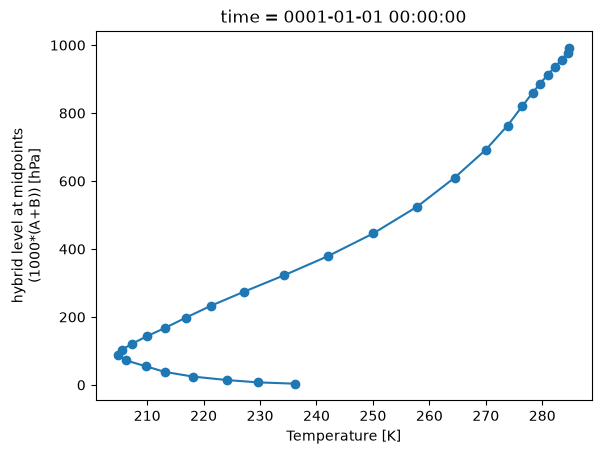

In [12]:
print('history streams:', driver.cam.history.streams)
with driver.cam.history.open('h0') as history:
    display(history)
    temperature = history['T'].isel(time=-1)
    horizontal_dims = [name for name in temperature.dims if name != 'lev']
    temperature.mean(dim=horizontal_dims).plot(y='lev', marker='o')